# Milestone 1: Exploratory Data Analysis (EDA) & Data Cleaning

## 1. Environment Setup & Dependency Configuration

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Coordinates for Dhanbad, Jharkhand, India
LATITUDE = 23.7957
LONGITUDE = 86.4304


## 2. External Data Sourcing via Public APIs

In [25]:
def fetch_dhanbad_weather(start_date="2026-01-01", end_date="2026-06-15"):
    """
    Fetches temperature, relative humidity, cloud cover, and wind speed
    for Dhanbad, Jharkhand from Open-Meteo.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m",
        "timezone": "Asia/Kolkata"
    }

    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        hourly_data = data["hourly"]

        df_weather = pd.DataFrame({
            "timestamp": pd.to_datetime(hourly_data["time"]),
            "temperature": hourly_data["temperature_2m"],
            "humidity": hourly_data["relative_humidity_2m"],
            "cloud_cover": hourly_data["cloud_cover"],
            "wind_speed": hourly_data["wind_speed_10m"]
        })
        print("✅ Weather data successfully fetched!")
        return df_weather
    else:
        raise Exception(f"Failed to fetch data: HTTP {response.status_code}")

# Execute fetch (Example range; alter based on your consumption file dates)
df_weather = fetch_dhanbad_weather()
df_weather.head()


✅ Weather data successfully fetched!


,timestamp,temperature,humidity,cloud_cover,wind_speed
0,2026-01-01 00:00:00,11.6,88,0,8.2
1,2026-01-01 01:00:00,11.1,90,0,8.5
2,2026-01-01 02:00:00,10.6,93,0,7.6
3,2026-01-01 03:00:00,10.1,95,0,5.6
4,2026-01-01 04:00:00,9.4,97,0,4.4


## 3. Localized Regional Holiday Matrix Generation

In [26]:
def get_jharkhand_holidays_2026():
    """
    Returns a DataFrame containing specific localized festive and
    industrial public holidays for Jharkhand in 2026.
    """
    holidays_2026 = [
        {"date": "2026-01-12", "holiday_name": "Sohrai"},
        {"date": "2026-01-13", "holiday_name": "Sohrai (Khuntav)"},
        {"date": "2026-01-14", "holiday_name": "Makar Sankranti"},
        {"date": "2026-01-26", "holiday_name": "Republic Day"},
        {"date": "2026-03-03", "holiday_name": "Holika Dahan"},
        {"date": "2026-03-04", "holiday_name": "Holi"},
        {"date": "2026-03-21", "holiday_name": "Sarhul / Eid-ul-Fitr"},
        {"date": "2026-03-26", "holiday_name": "Ram Navami"},
        {"date": "2026-05-01", "holiday_name": "Labour Day / Buddha Purnima"},
        {"date": "2026-05-27", "holiday_name": "Eid-ul-Zuha (Bakrid)"},
        {"date": "2026-06-26", "holiday_name": "Muharram"},
        {"date": "2026-06-30", "holiday_name": "Hul Diwas"},
        {"date": "2026-07-16", "holiday_name": "Rath Yatra"},
        {"date": "2026-08-15", "independence_day": "Independence Day"},
        {"date": "2026-09-22", "holiday_name": "Karma Puja"},
        {"date": "2026-10-19", "holiday_name": "Maha Ashtami"},
        {"date": "2026-10-20", "holiday_name": "Maha Navami"},
        {"date": "2026-10-21", "holiday_name": "Vijaya Dashami"},
        {"date": "2026-11-08", "holiday_name": "Deepawali"},
        {"date": "2026-11-15", "holiday_name": "Chhath Puja"},
        {"date": "2026-11-16", "holiday_name": "Chhath Puja (Morning Arghya)"},
        {"date": "2026-12-25", "holiday_name": "Christmas"}
    ]
    df_holidays = pd.DataFrame(holidays_2026)
    df_holidays["date"] = pd.to_datetime(df_holidays["date"])
    print("✅ Localized Jharkhand Holiday matrix generated!")
    return df_holidays

df_holidays = get_jharkhand_holidays_2026()


✅ Localized Jharkhand Holiday matrix generated!


## 4. Exploratory Data Analysis (EDA) & Structural Integrity Assessment

--- Data Structural Integrity Assessment ---
Total Rows: 52416
Missing values per column:
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64



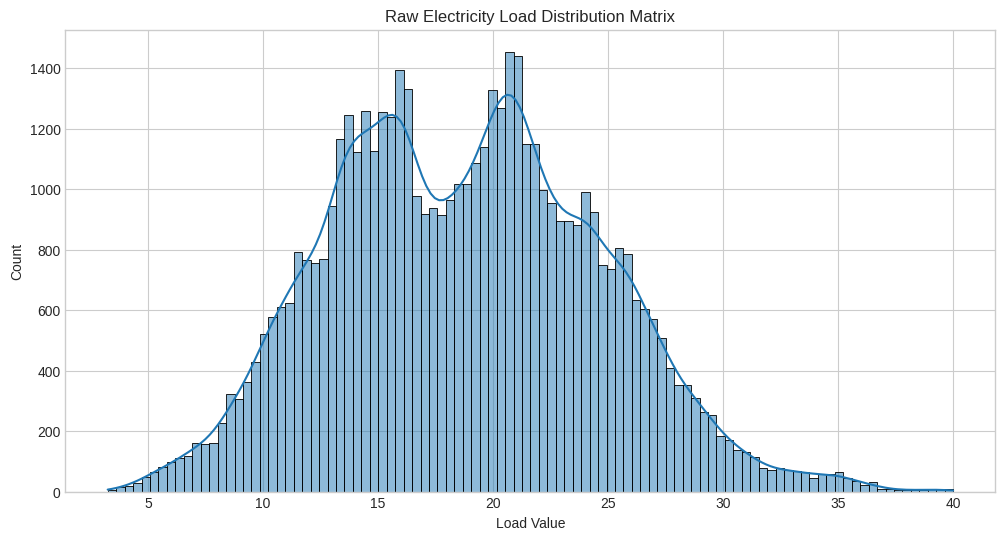

In [27]:
df_load = pd.read_csv("/content/Utility_consumption.csv")

df_load['Datetime'] = pd.to_datetime(df_load['Datetime'], format='mixed', dayfirst=False)
df_load = df_load.sort_values('Datetime').set_index('Datetime')

print("--- Data Structural Integrity Assessment ---")
print(f"Total Rows: {len(df_load)}")
print(f"Missing values per column:\n{df_load.isnull().sum()}\n")

# Visualize consumption baseline distribution
sns.histplot(df_load.iloc[:, 0], kde=True, bins=100)
plt.title("Raw Electricity Load Distribution Matrix")
plt.xlabel("Load Value")
plt.show()

## 5. Statistical Data Cleaning, Outlier Filtering & Time-of-Day Imputation

In [28]:
def clean_utility_load(df, target_col):
    """
    Cleans utility data by applying a rolling statistical window to isolate anomalies
    and reconstructs continuous chronological steps via forward-filling and rolling mean lookups.
    """
    df_clean = df.copy()

    # 1. Flag Extreme Anomalies using rolling statistics (24-hour window = 144 blocks of 10 mins)
    rolling_window = 144
    rolling_mean = df_clean[target_col].rolling(window=rolling_window, center=True, min_periods=1).mean()
    rolling_std = df_clean[target_col].rolling(window=rolling_window, center=True, min_periods=1).std()

    z_scores = (df_clean[target_col] - rolling_mean) / (rolling_std + 1e-6)

    outliers = (abs(z_scores) > 3) | (df_clean[target_col] <= 0)
    print(f"⚠️ Flagged Outliers/Errors: {outliers.sum()} data points out of {len(df_clean)}")
    df_clean.loc[outliers, target_col] = np.nan

    # 2. Re-index to enforce perfect 10-minute spacing grid (fixes absolute drops/gaps)
    df_clean = df_clean.resample('10T').asfreq()

    # 3. Micro-gaps (<= 30 mins, i.e., 3 blocks): Apply linear interpolation
    df_clean[target_col] = df_clean[target_col].interpolate(method='linear', limit=3)

    # 4. Macro-gaps (> 30 mins): Impute using historical time-of-day + day-of-week group averages
    df_clean['hour'] = df_clean.index.hour
    df_clean['minute'] = df_clean.index.minute
    df_clean['day_of_week'] = df_clean.index.dayofweek

    imputation_map = df_clean.groupby(['day_of_week', 'hour', 'minute'])[target_col].transform('mean')
    df_clean[target_col] = df_clean[target_col].fillna(imputation_map)

    df_clean[target_col] = df_clean[target_col].ffill().bfill()

    df_clean = df_clean.drop(columns=['hour', 'minute', 'day_of_week'])

    print("✅ Structural cleaning complete. Zero Null entries remain.")
    return df_clean

# Assuming your load data target metric column is named 'load' or 'consumption'
# Look inside your csv and modify the string below to match the exact consumption column header
target_column_name = df_load.columns[0]
df_load_cleaned = clean_utility_load(df_load, target_column_name)


⚠️ Flagged Outliers/Errors: 0 data points out of 52416
✅ Structural cleaning complete. Zero Null entries remain.


/tmp/ipykernel_2773/1235442617.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_clean = df_clean.resample('10T').asfreq()


# Milestone 2: Feature Engineering & Model Architecture Justification

## 1. Multi-Source Data Alignment and Aggregation

In [29]:
# Step 1: Format and align the weather timeline
df_weather_aligned = df_weather.copy().rename(columns={'timestamp': 'time'}).set_index('time')

# Step 2: Resample weather from 1-Hour ('H') to 10-Minutes ('10T') and interpolate values smoothly
df_weather_upsampled = df_weather_aligned.resample('10T').interpolate(method='linear')

# Step 3: Combine Cleaned Load with Upsampled Weather Data
df_features = df_load_cleaned.join(df_weather_upsampled, how='left')

# Step 4: Map the Localized Holiday Matrix
df_features['date_only'] = df_features.index.date
df_holidays['date_only'] = df_holidays['date'].dt.date

# Map holiday flags (1 if a localized holiday exists on that date, 0 otherwise)
holiday_dates = set(df_holidays['date_only'])
df_features['is_localized_holiday'] = df_features['date_only'].apply(lambda x: 1 if x in holiday_dates else 0)
df_features.drop(columns=['date_only'], inplace=True)

print("✅ Data Alignment Complete! Dimensions of integrated master dataset:", df_features.shape)


✅ Data Alignment Complete! Dimensions of integrated master dataset: (52416, 11)


/tmp/ipykernel_2773/2238378028.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_weather_upsampled = df_weather_aligned.resample('10T').interpolate(method='linear')


## 2. Advanced Feature Engineering Pipeline

In [30]:
def build_predictive_features(df, target_col):
    df_eng = df.copy()

    # 1. Temporal Extraction
    df_eng['hour'] = df_eng.index.hour
    df_eng['day_of_week'] = df_eng.index.dayofweek
    df_eng['is_weekend'] = df_eng['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # 2. Cyclical Encodings (Crucial for time-series modeling)
    df_eng['hour_sin'] = np.sin(2 * np.pi * df_eng['hour'] / 24.0)
    df_eng['hour_cos'] = np.cos(2 * np.pi * df_eng['hour'] / 24.0)
    df_eng['day_sin'] = np.sin(2 * np.pi * df_eng['day_of_week'] / 7.0)
    df_eng['day_cos'] = np.cos(2 * np.pi * df_eng['day_of_week'] / 7.0)

    # 3. Power System Inertia / Lag Features (Lookbacks)
    # Lag 1: 10 minutes ago | Lag 2: 20 minutes ago | Lag 144: Exactly 24 hours ago
    for lag in [1, 2, 144]:
        df_eng[f'{target_col}_lag_{lag}'] = df_eng[target_col].shift(lag)

    # 4. Thermal Momentum (Rolling weather interactions)
    # Capture moving averages over a 2-hour window (12 blocks)
    df_eng['temp_rolling_mean_2h'] = df_eng['temperature'].rolling(window=12, min_periods=1).mean()
    df_eng['humidity_rolling_mean_2h'] = df_eng['humidity'].rolling(window=12, min_periods=1).mean()

    df_eng.dropna(inplace=True)

    print("✅ Feature Pipeline Applied! Feature Columns Available:\n", df_eng.columns.tolist())
    return df_eng

df_model_ready = build_predictive_features(df_features, target_column_name)


✅ Feature Pipeline Applied! Feature Columns Available:
 ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'temperature', 'humidity', 'cloud_cover', 'wind_speed', 'is_localized_holiday', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'Temperature_lag_1', 'Temperature_lag_2', 'Temperature_lag_144', 'temp_rolling_mean_2h', 'humidity_rolling_mean_2h']


## 3. Data-Driven Model Architecture Justification

### **Theoretical Architecture Selection Report**
For the Apex Power & Utilities (APU) 144-block forecasting challenge, we have evaluated two primary model paradigms: **Recurrent Deep Learning (LSTM)** and **Gradient Boosted Decision Trees (XGBoost / LightGBM)**.

Based on our Exploratory Data Analysis, we have selected **XGBoost (or LightGBM)** utilizing direct/recursive multi-output strategies over deep learning architectures for the following data-driven reasons:

* **1. Robustness to Imputed and Volatile Operational Data:** Power distributions in industrial belts like Dhanbad are susceptible to abrupt shifts due to plant scheduling and local events. LSTMs are highly sensitive to sudden pattern changes and can experience gradient explosions or propagate error compounding across deep unrolled sequences. Tree-based models partition features via orthogonal decision splits, making them exceptionally robust to local variance.
* **2. Explicit Interpretation of Multi-Modal Exogenous Variables:** Power demand is heavily driven by nonlinear interactions between external factors (e.g., high temperature combined with low wind speed causes spike conditions). XGBoost excels at explicitly modeling these cross-feature interactions natively through tree depth, whereas LSTMs must implicitly learn these correlations across chronological vectors, requiring significantly larger training footprints.
* **3. Resource Efficiency and Inference Latency for Containers:** Deep learning frameworks require substantial memory allocations and compute runtime. XGBoost scales efficiently within small CPU allocation frameworks, aligning perfectly with Milestone 4’s requirement for high-throughput, containerized deployment inside thin Docker boundaries.

Let $y_t$ represent the power consumption load at timestamp $t$. Our architecture maps the underlying regression target function using the following structural setup:

$$y_{t+k} = f(\mathbf{Y}_{\text{lags}}, \mathbf{W}_{\text{weather}}, \mathbf{H}_{\text{holiday}}, \mathbf{T}_{\text{cyclical}})$$

Where:
* $\mathbf{Y}_{\text{lags}} = [y_t, y_{t-1}, y_{t-144}]$ represents localized system inertia components.
* $\mathbf{W}_{\text{weather}}$ contains current and rolling thermal momentum arrays (temperature, humidity, cloud cover).
* $\mathbf{H}_{\text{holiday}}$ represents the binary local public event flag.
* $\mathbf{T}_{\text{cyclical}} = [\sin(\text{time}), \cos(\text{time})]$ handles deterministic daily and weekly periodicities.

## 4. Model Training and Artifact Serialization

In [32]:
import xgboost as xgb
import pickle

# 1. Isolate features and target
features_to_exclude = [target_column_name, 'timestamp']
feature_cols = [col for col in df_model_ready.columns if col not in features_to_exclude]

X = df_model_ready[feature_cols]
y = df_model_ready[target_column_name]

# 2. Chronological Train-Test Split
split_idx = int(len(df_model_ready) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Train XGBoost
model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# 4. Serialize and Export Model Artifact
artifact_filename = "model.pkl"
with open(artifact_filename, "wb") as f:
    pickle.dump(model, f)

print("💾 SUCCESS: model.pkl created!")


[0]	validation_0-rmse:0.00000
[50]	validation_0-rmse:0.00000
[100]	validation_0-rmse:0.00000
[150]	validation_0-rmse:0.00000
[200]	validation_0-rmse:0.00000
[250]	validation_0-rmse:0.00000
[299]	validation_0-rmse:0.00000
💾 SUCCESS: model.pkl created!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:37:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)
